# Welcome to Colab!

In [1]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split,RandomizedSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/dataset_A_training (1).csv')
display(df.head())

,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0


In [3]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   flu_concern                  4744 non-null   float64
 2   flu_knowledge                4733 non-null   float64
 3   behavioral_antiviral_meds    4742 non-null   float64
 4   behavioral_avoidance         4724 non-null   float64
 5   behavioral_face_mask         4753 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4747 non-null   float64
 9   behavioral_touch_face        4737 non-null   float64
 10  doctor_recc_seasonal         4435 non-null   float64
 11  chronic_med_condition        4568 non-null   float64
 12  child_under_6_months         4604 non-null   float64
 13  health_worker     

None

In [4]:
#missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False))

,Missing Count,Missing Percentage
employment_sector,2314,48.654331
health_insurance,1925,40.475189
income_poverty,790,16.610597
rent_or_own,381,8.010934
doctor_recc_seasonal,321,6.749369
education,270,5.677040
employment_status,269,5.656013
marital_status,265,5.571909
chronic_med_condition,188,3.952902
child_under_6_months,152,3.195963


In [5]:
#Feature selection
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical Features ({len(categorical_features)}): {categorical_features}")

Numerical Features (21): ['respondent_id', 'flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children', 'seasonal_vaccine']
Categorical Features (10): ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


In [6]:
for col in categorical_features:
    if df[col].isnull().any():
        df[col] = df[col].fillna('Missing')

print("Missing values in categorical features handled.")

Missing values in categorical features handled.


/tmp/ipykernel_71851/3937969654.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='seasonal_vaccine', data=df, palette='viridis')


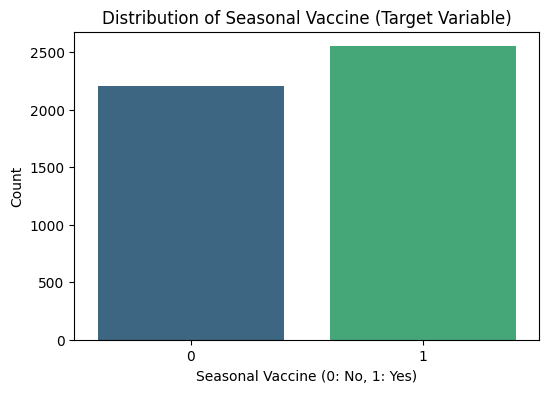

In [7]:
#Target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='seasonal_vaccine', data=df, palette='viridis')
plt.title('Distribution of Seasonal Vaccine (Target Variable)')
plt.xlabel('Seasonal Vaccine (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

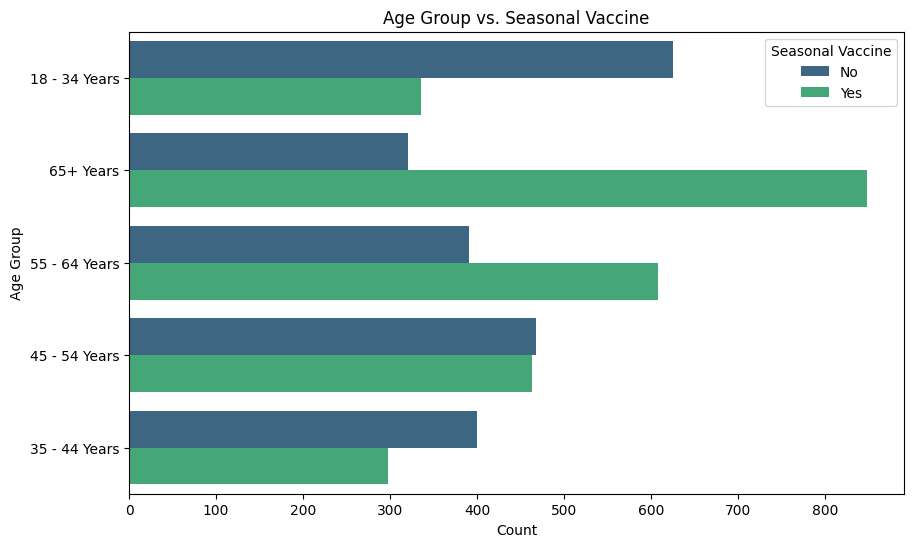

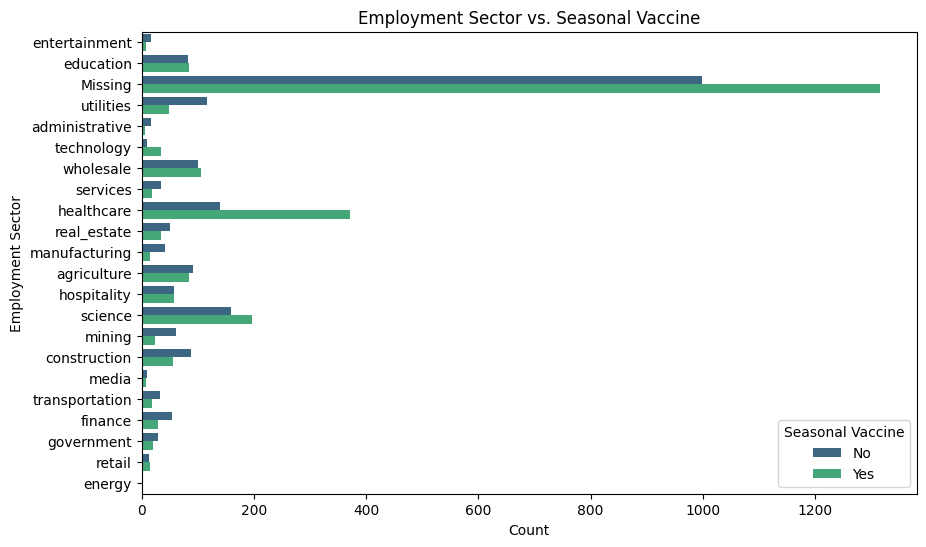

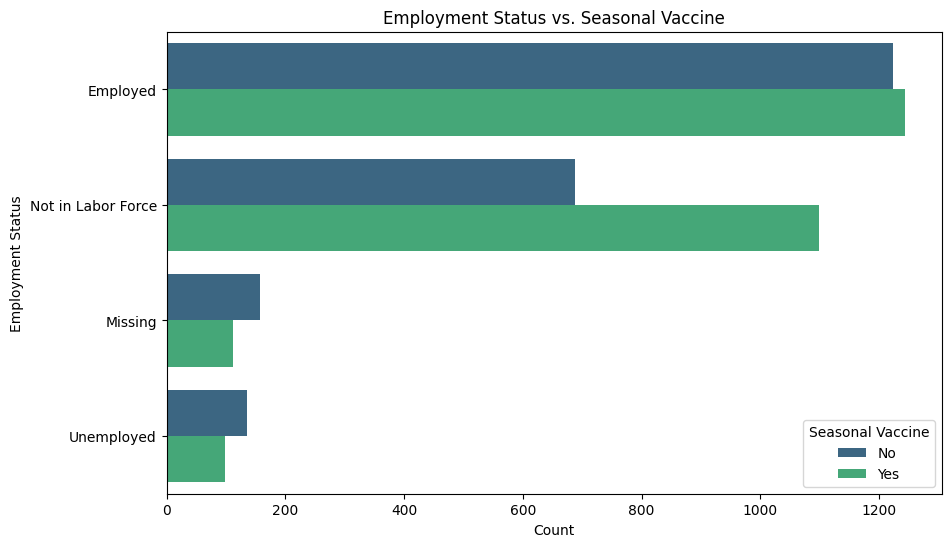

In [8]:
#Relation of categorical features with target variable

plt.figure(figsize=(10, 6))
sns.countplot(y='age_group', hue='seasonal_vaccine', data=df, palette='viridis')
plt.title('Age Group vs. Seasonal Vaccine')
plt.xlabel('Count')
plt.ylabel('Age Group')
plt.legend(title='Seasonal Vaccine', labels=['No', 'Yes'])
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(y='employment_sector', hue='seasonal_vaccine', data=df, palette='viridis')
plt.title('Employment Sector vs. Seasonal Vaccine')
plt.xlabel('Count')
plt.ylabel('Employment Sector')
plt.legend(title='Seasonal Vaccine', labels=['No', 'Yes'])
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(y='employment_status', hue='seasonal_vaccine', data=df, palette='viridis')
plt.title('Employment Status vs. Seasonal Vaccine')
plt.xlabel('Count')
plt.ylabel('Employment Status')
plt.legend(title='Seasonal Vaccine', labels=['No', 'Yes'])
plt.show()

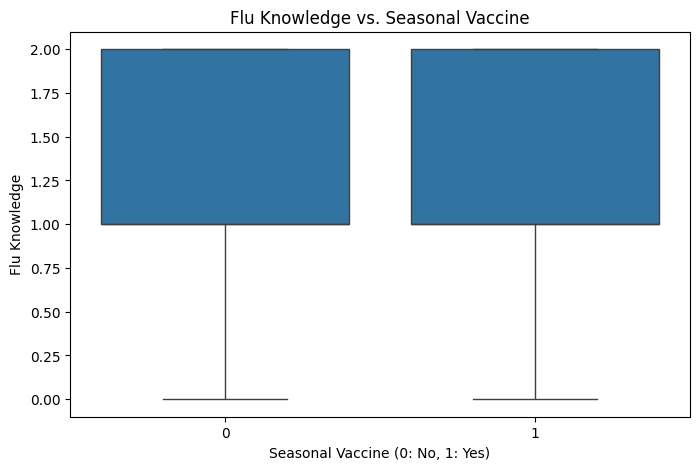

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='seasonal_vaccine', y='flu_knowledge', data=df)
plt.title('Flu Knowledge vs. Seasonal Vaccine')
plt.xlabel('Seasonal Vaccine (0: No, 1: Yes)')
plt.ylabel('Flu Knowledge')
plt.show()

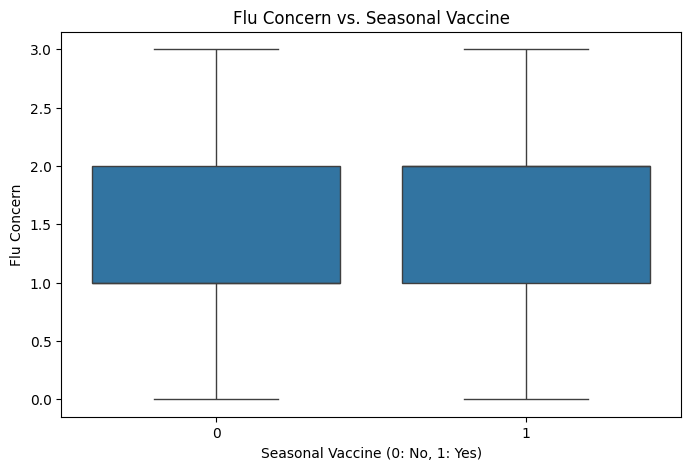

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='seasonal_vaccine', y='flu_concern', data=df)
plt.title('Flu Concern vs. Seasonal Vaccine')
plt.xlabel('Seasonal Vaccine (0: No, 1: Yes)')
plt.ylabel('Flu Concern')
plt.show()

In [12]:
#one hot encoding categorical features
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)
display(df_encoded.head())

,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_sector_media,employment_sector_mining,employment_sector_real_estate,employment_sector_retail,employment_sector_science,employment_sector_services,employment_sector_technology,employment_sector_transportation,employment_sector_utilities,employment_sector_wholesale
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,False,False,False,False,False,False,False,False,True,False
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,False,False,False,False,False,False,False,False,False,False


In [13]:
# Defining features (X) and target (y)
X = df_encoded.drop(columns=['respondent_id', 'seasonal_vaccine'])
y = df_encoded['seasonal_vaccine']

# Spliting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3804, 64)
X_test shape: (952, 64)
y_train shape: (3804,)
y_test shape: (952,)


### Model Training and Evaluation

In [14]:
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
import re


def sanitize_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:

        new_col = re.sub(r'[^A-Za-z0-9_]+', '_', col)
        new_cols.append(new_col)
    df.columns = new_cols
    return df


X_train_sanitized = sanitize_col_names(X_train.copy())
X_test_sanitized = sanitize_col_names(X_test.copy())





In [15]:

# Identifying numerical columns that might still have NaNs after one-hot encoding
numerical_cols_with_nans_train = X_train_sanitized.select_dtypes(include=np.number).columns[X_train_sanitized.select_dtypes(include=np.number).isnull().any()].tolist()
numerical_cols_with_nans_test = X_test_sanitized.select_dtypes(include=np.number).columns[X_test_sanitized.select_dtypes(include=np.number).isnull().any()].tolist()

# Combining and get unique numerical columns that need imputation
all_numerical_cols_to_impute = list(set(numerical_cols_with_nans_train + numerical_cols_with_nans_test))

In [16]:

# Imputing missing values in numerical columns using median strategy
imputer = SimpleImputer(strategy='median')

if all_numerical_cols_to_impute:
    X_train_sanitized[all_numerical_cols_to_impute] = imputer.fit_transform(X_train_sanitized[all_numerical_cols_to_impute])
    X_test_sanitized[all_numerical_cols_to_impute] = imputer.transform(X_test_sanitized[all_numerical_cols_to_impute])

In [17]:

# Scaling all numerical columns after imputation
scaler = StandardScaler()
all_numerical_cols = X_train_sanitized.select_dtypes(include=np.number).columns.tolist()

X_train_scaled = X_train_sanitized.copy()
X_test_scaled = X_test_sanitized.copy()

X_train_scaled[all_numerical_cols] = scaler.fit_transform(X_train_sanitized[all_numerical_cols])
X_test_scaled[all_numerical_cols] = scaler.transform(X_test_sanitized[all_numerical_cols])

In [18]:

# Initializing the XGBoost classifier
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Training the model
xgb_model.fit(X_train_scaled, y_train)



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:28:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

### Model Prediction and Evaluation

In [19]:
# Making predictions on the test set
y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]


# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nAccuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)
print(f"\nROC AUC Score: {roc_auc:.4f}")


Accuracy: 0.7489

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.75      0.74       441
           1       0.78      0.75      0.76       511

    accuracy                           0.75       952
   macro avg       0.75      0.75      0.75       952
weighted avg       0.75      0.75      0.75       952


Confusion Matrix:
[[332 109]
 [130 381]]

ROC AUC Score: 0.8155


### ROC Curve

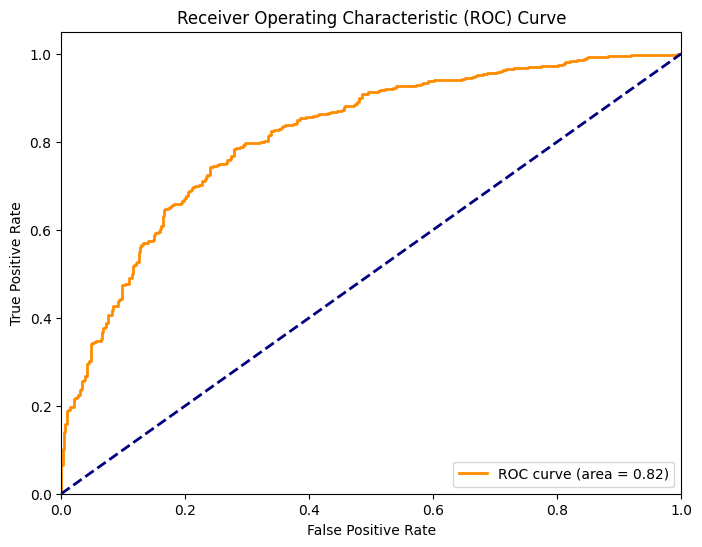

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

### Parameter Tuning with RandomizedSearchCV

In [21]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'lambda': [0.1, 0.5, 1, 1.5],
    'alpha': [0, 0.1, 0.5, 1]
}


# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=50, # Number of parameter settings that are sampled. Trade-off between runtime and quality of the solution.
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train_scaled, y_train)

print("RandomizedSearchCV completed.")
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best ROC AUC score: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:30:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV completed.
Best parameters found: {'subsample': 0.9, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'lambda': 0.1, 'gamma': 0, 'colsample_bytree': 0.8, 'alpha': 0}
Best ROC AUC score: 0.8468


### Training and Evaluating XGBoost with Best Parameters

In [22]:
# Train a new XGBoost model with the best parameters found
best_xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', **random_search.best_params_)
best_xgb_model.fit(X_train_scaled, y_train)


# Make predictions on the test set with the best model
y_pred_tuned = best_xgb_model.predict(X_test_scaled)
y_pred_proba_tuned = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
report_tuned = classification_report(y_test, y_pred_tuned)
conf_matrix_tuned = confusion_matrix(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)

print(f"\nAccuracy (Tuned Model): {accuracy_tuned:.4f}")
print("\nClassification Report (Tuned Model):")
print(report_tuned)
print("\nConfusion Matrix (Tuned Model):")
print(conf_matrix_tuned)
print(f"\nROC AUC Score (Tuned Model): {roc_auc_tuned:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:30:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Accuracy (Tuned Model): 0.7899

Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.78      0.76      0.77       441
           1       0.80      0.82      0.81       511

    accuracy                           0.79       952
   macro avg       0.79      0.79      0.79       952
weighted avg       0.79      0.79      0.79       952


Confusion Matrix (Tuned Model):
[[335 106]
 [ 94 417]]

ROC AUC Score (Tuned Model): 0.8522


### ROC Curve for Tuned Model

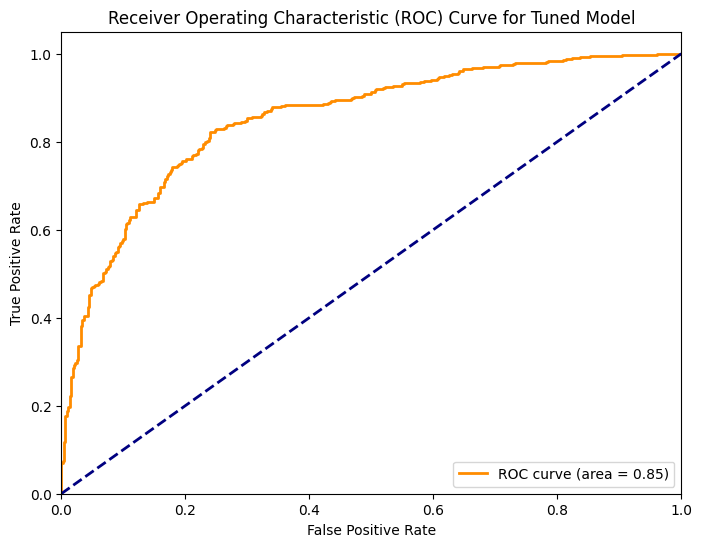

In [23]:

fpr_tuned, tpr_tuned, thresholds_tuned = roc_curve(y_test, y_pred_proba_tuned)
roc_auc_plot_tuned = auc(fpr_tuned, tpr_tuned)

plt.figure(figsize=(8, 6))
plt.plot(fpr_tuned, tpr_tuned, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_plot_tuned:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Tuned Model')
plt.legend(loc='lower right')
plt.show()